<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/week8_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
path='/content/drive/MyDrive/Dataset/processed_data.csv'

In [3]:
df=pd.read_csv(path)

In [4]:
df.head(5)

,text,sentiment,Time of Tweet,Age of User,Land Area (Km²),Continent,Density_Level,Population_Group
0,Sooo SAD I will miss you here in San Diego!!!,negative,noon,21-30,27400.0,EU,Medium,Medium
1,my boss is bullying me...,negative,night,31-45,2381740.0,AF,Low,Medium
2,what interview! leave me alone,negative,morning,46-60,470.0,EU,Medium,Low
3,"Sons of ****, why couldn`t they put them on t...",negative,noon,60-70,1246700.0,AF,Low,Medium
4,2am feedings for the baby are fun when he is a...,positive,morning,0-20,2736690.0,SA,Low,Medium


### Split data into training and test sets

In [5]:
from sklearn.model_selection import train_test_split
feature=df.drop('sentiment',axis=1)
label=df['sentiment']
X_train, X_test,y_train,y_test= train_test_split(feature,label, test_size=0.20, random_state=0)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (13090, 7)
Test set shape: (3273, 7)


## Count unique words in the 'text' column of the training set

In [6]:
X_train.head()

,text,Time of Tweet,Age of User,Land Area (Km²),Continent,Density_Level,Population_Group
2554,"come home, then. Not so boring here.",morning,0-20,62710.0,AS,Medium,Medium
5412,Is feeling like he has a bad flu. Yes. Bad. Flu.,morning,46-60,25680.0,AF,Medium,Medium
7503,have a lok at EF too! they are jummy,morning,46-60,365000.0,EU,Low,Medium
8694,"PINKPOP weekend & I`ve got NO tickets, meaning...",night,31-45,60.0,EU,High,Low
194,seriously bored without anyone to talk to... b...,morning,46-60,24670.0,AF,High,Medium


In [7]:
from sklearn.feature_extraction.text import  TfidfVectorizer
tf=TfidfVectorizer()

In [8]:
corpus=X_train['text']

In [9]:
tf.fit_transform(corpus)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 154318 stored elements and shape (13090, 16407)>

In [10]:
tf.get_feature_names_out()

array(['00', '000', '00am', ..., 'â½you', 'â½z', 'â½ã'], dtype=object)

In [11]:
tf.get_feature_names_out().shape[0]

16407

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train['Land Area (Km²)']=scaler.fit_transform(X_train[['Land Area (Km²)']])
X_test['Land Area (Km²)']=scaler.transform(X_test[['Land Area (Km²)']])

In [13]:
from sklearn.preprocessing import OrdinalEncoder

mapp = ["Low", "Medium", "High"]
# The categories parameter should be a list of lists, one list for each feature
ord = OrdinalEncoder(categories=[mapp, mapp])
X_train[['Density_Level', 'Population_Group']] = ord.fit_transform(X_train[['Density_Level', 'Population_Group']])
X_test[['Density_Level', 'Population_Group']] = ord.transform(X_test[['Density_Level', 'Population_Group']])

In [14]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

one = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore').set_output(transform='pandas')

categorical_cols = ['Age of User', 'Time of Tweet', 'Continent']

# Fit and transform on X_train
one_hot_encoded_train_df = one.fit_transform(X_train[categorical_cols])

# Drop original categorical columns from X_train and concatenate new ones
X_train = pd.concat([X_train.drop(columns=categorical_cols), one_hot_encoded_train_df], axis=1)

# Transform X_test using the encoder fitted on X_train
one_hot_encoded_test_df = one.transform(X_test[categorical_cols])

# Drop original categorical columns from X_test and concatenate new ones
X_test = pd.concat([X_test.drop(columns=categorical_cols), one_hot_encoded_test_df], axis=1)

print("X_train shape after One-Hot Encoding:", X_train.shape)
print("X_test shape after One-Hot Encoding:", X_test.shape)

X_train shape after One-Hot Encoding: (13090, 17)
X_test shape after One-Hot Encoding: (3273, 17)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(lowercase=True,stop_words='english',max_features=5000,ngram_range=(1,2),token_pattern=r'(?u)\b\w\w+\b|[@#]\w+',strip_accents='unicode')

In [16]:

# Apply TF-IDF Vectorization to the 'text' column
X_train_text_features_sparse = tf.fit_transform(X_train['text'])
X_test_text_features_sparse = tf.transform(X_test['text'])

# Get feature names from the TF-IDF vectorizer
tfidf_feature_names = tf.get_feature_names_out()

# Convert sparse matrices to DataFrame, preserving original indices
X_train_text_df = pd.DataFrame(X_train_text_features_sparse.toarray(), columns=tfidf_feature_names, index=X_train.index)
X_test_text_df = pd.DataFrame(X_test_text_features_sparse.toarray(), columns=tfidf_feature_names, index=X_test.index)

# Drop the original 'text' column from X_train and X_test
X_train = X_train.drop(columns=['text'])
X_test = X_test.drop(columns=['text'])

# Concatenate the TF-IDF features with the rest of X_train and X_test
X_train = pd.concat([X_train, X_train_text_df], axis=1)
X_test = pd.concat([X_test, X_test_text_df], axis=1)

print(f"X_train shape after TF-IDF replacement: {X_train.shape}")
print(f"X_test shape after TF-IDF replacement: {X_test.shape}")

# Display the head of the modified DataFrames to show the new structure
print("\nX_train head after TF-IDF replacement:")
display(X_train.head())
print("\nX_test head after TF-IDF replacement:")
display(X_test.head())

X_train shape after TF-IDF replacement: (13090, 5016)
X_test shape after TF-IDF replacement: (3273, 5016)

X_train head after TF-IDF replacement:


,Land Area (Km²),Density_Level,Population_Group,Age of User_21-30,Age of User_31-45,Age of User_46-60,Age of User_60-70,Age of User_70-100,Time of Tweet_night,Time of Tweet_noon,...,yucky,yum,yum yum,yummy,yup,zealand,zero,zombie,zombies,zone
2554,-0.330473,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5412,-0.350964,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7503,-0.163190,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8694,-0.365142,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
194,-0.351523,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test head after TF-IDF replacement:


,Land Area (Km²),Density_Level,Population_Group,Age of User_21-30,Age of User_31-45,Age of User_46-60,Age of User_60-70,Age of User_70-100,Time of Tweet_night,Time of Tweet_noon,...,yucky,yum,yum yum,yummy,yup,zealand,zero,zombie,zombies,zone
13023,-0.259036,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2607,-0.239258,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9125,-0.364921,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3831,-0.330755,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1534,-0.349614,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X_test[:5].sum().sum()

np.float64(26.88577386940662)

In [18]:
X_train_copy=X_train.drop('Land Area (Km²)',axis=1).copy()
X_test_copy=X_test.drop('Land Area (Km²)',axis=1).copy()

In [19]:
X_test_copy.head(3)

,Density_Level,Population_Group,Age of User_21-30,Age of User_31-45,Age of User_46-60,Age of User_60-70,Age of User_70-100,Time of Tweet_night,Time of Tweet_noon,Continent_AS,...,yucky,yum,yum yum,yummy,yup,zealand,zero,zombie,zombies,zone
13023,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2607,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9125,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.naive_bayes import MultinomialNB
mn = MultinomialNB()

In [21]:
mn.fit(X_train_copy,y_train)

MultinomialNB()

In [22]:
mn_pred=mn.predict(X_test_copy)
mn_pred[:4]

array(['negative', 'negative', 'positive', 'positive'], dtype='<U8')

In [23]:
y_test[:4]

,sentiment
13023,negative
2607,negative
9125,positive
3831,negative


In [24]:
from sklearn.metrics import log_loss
mn_pred_proba = mn.predict_proba(X_test_copy)
log_loss(y_test, mn_pred_proba)

0.3687388551646365

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [26]:
rf_pre=rf.predict(X_test)

In [27]:
rf_pre

array(['negative', 'negative', 'positive', ..., 'negative', 'positive',
       'positive'], dtype=object)

In [28]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,rf_pre)

array([[1348,  184],
       [ 267, 1474]])

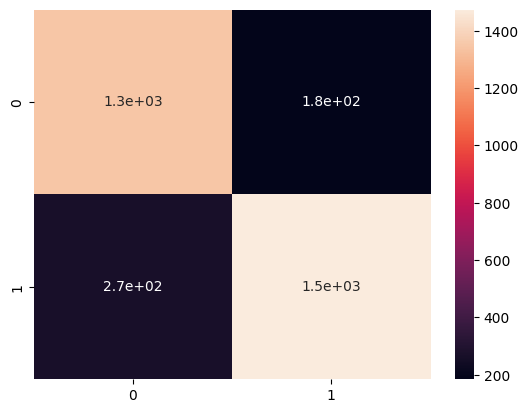

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,rf_pre),annot=True)
plt.show()

In [30]:
rf.classes_

array(['negative', 'positive'], dtype=object)

In [31]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Calculate individual metrics
accuracy = accuracy_score(y_test, rf_pre)
precision = precision_score(y_test, rf_pre, pos_label='positive')
recall = recall_score(y_test, rf_pre, pos_label='positive')
f1 = f1_score(y_test, rf_pre, pos_label='positive')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Positive Class): {precision:.4f}")
print(f"Recall (Positive Class): {recall:.4f}")
print(f"F1-Score (Positive Class): {f1:.4f}")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pre))

Accuracy: 0.8622
Precision (Positive Class): 0.8890
Recall (Positive Class): 0.8466
F1-Score (Positive Class): 0.8673

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.88      0.86      1532
    positive       0.89      0.85      0.87      1741

    accuracy                           0.86      3273
   macro avg       0.86      0.86      0.86      3273
weighted avg       0.86      0.86      0.86      3273



In [34]:
from sklearn.feature_selection import  RFECV
from sklearn.linear_model import LogisticRegression
rfcv=RFECV(LogisticRegression(random_state=42,max_iter=1000),step=100,n_jobs=-1)

In [35]:
rfcv.fit(X_train,y_train)

RFECV(estimator=LogisticRegression(max_iter=1000, random_state=42), n_jobs=-1,
      step=100)

In [39]:
rfcv.n_features_

np.int64(4216)